In [1]:
import pandas as pd
df = pd.read_csv("loan_encoded.csv")
df.head(10)

,loan_amnt,term,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,dti,...,recoveries,collection_recovery_fee,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,purpose_,addr_state_
0,2500.0,60,3,0.5,3,30000.0,1,48,10,1.00,...,117.08,1.11,28,0.0,0.0,0.0,0.0,32068.620045,0,10
1,10000.0,36,3,10.0,3,49200.0,1,48,1,20.00,...,0.00,0.00,12,0.0,0.0,0.0,0.0,32068.620045,9,4
2,3000.0,60,2,1.0,3,80000.0,1,48,2,17.94,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,9,37
3,5000.0,36,1,3.0,3,36000.0,1,48,1,11.20,...,0.00,0.00,4,0.0,0.0,0.0,0.0,32068.620045,13,3
4,7000.0,60,3,8.0,3,47004.0,3,48,2,23.51,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,2,27
5,3000.0,36,5,9.0,3,48000.0,1,48,1,5.35,...,0.00,0.00,13,0.0,0.0,0.0,0.0,32068.620045,0,4
6,5375.0,60,2,0.5,3,15000.0,2,48,10,18.08,...,269.29,2.52,34,0.0,0.0,0.0,0.0,32068.620045,9,43
7,6500.0,60,3,5.0,1,72000.0,3,48,1,16.12,...,0.00,0.00,1,0.0,0.0,0.0,0.0,32068.620045,2,3
8,12000.0,36,2,10.0,1,75000.0,1,48,1,10.78,...,0.00,0.00,29,0.0,0.0,0.0,0.0,32068.620045,2,4
9,9000.0,36,3,0.5,3,30000.0,1,48,10,10.08,...,444.30,4.16,38,0.0,0.0,0.0,0.0,32068.620045,2,45


In [2]:
df.grade.value_counts()

grade
2    234883
3    226744
1    137247
4    128448
5     65552
6     21406
7      5123
Name: count, dtype: int64

基线模型CV准确率: 0.7373 +/- 0.0022
基线模型CV加权F1: 0.7335 +/- 0.0022
基线模型测试集准确率: 0.7446
基线模型测试集加权F1: 0.7411


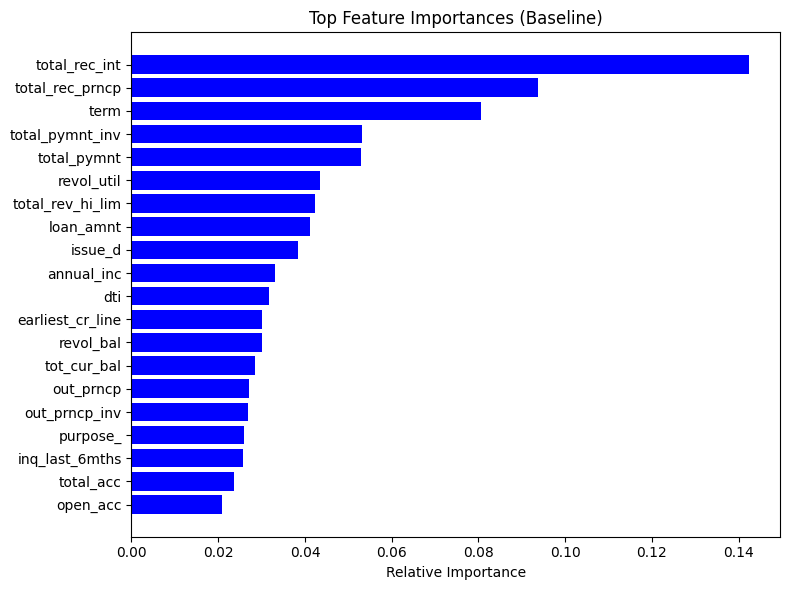

In [3]:
# 基线模型：分层切分 + 5折交叉验证 + 全训练集重训后测试（低内存安全版）
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from joblib import parallel_backend
import numpy as np
import matplotlib.pyplot as plt

# 4核16GB推荐：外层CV串行，内部线程并行
CV_N_JOBS = 1
RF_N_JOBS = 2

def run_rf_experiment(X_train_full, y_train_full, X_test, y_test, model_params, cv, model_label):
    # 用 threading backend 降低多进程复制数据造成的内存峰值
    with parallel_backend('threading'):
        cv_scores = cross_validate(
            RandomForestClassifier(**model_params),
            X_train_full, y_train_full,
            cv=cv,
            scoring=['accuracy', 'f1_weighted'],
            n_jobs=CV_N_JOBS,
            pre_dispatch='1*n_jobs'
        )
    print(f"{model_label}CV准确率: {cv_scores['test_accuracy'].mean():.4f} +/- {cv_scores['test_accuracy'].std():.4f}")
    print(f"{model_label}CV加权F1: {cv_scores['test_f1_weighted'].mean():.4f} +/- {cv_scores['test_f1_weighted'].std():.4f}")

    model = RandomForestClassifier(**model_params)
    model.fit(X_train_full, y_train_full)

    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    print(f"{model_label}测试集准确率: {test_accuracy:.4f}")
    print(f"{model_label}测试集加权F1: {test_f1:.4f}")

    return model, cv_scores, y_test_pred, test_accuracy, test_f1

def plot_top_feature_importances(model, feature_columns, title, color='b', top_n=20):
    feature_importances = model.feature_importances_
    indices = np.argsort(feature_importances)[::-1][:top_n]

    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.barh(range(len(indices)), feature_importances[indices], color=color, align='center')
    plt.yticks(range(len(indices)), [feature_columns[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

X = df.drop('grade', axis=1)
y = df['grade']

# 切分测试集（10%），训练池用于交叉验证和最终重训
X_train_full, X_test_base, y_train_full, y_test_base = train_test_split(
    X, y,
    test_size=0.1,
    random_state=123,
    stratify=y
)

model_params = dict(
    n_estimators=132,
    criterion='entropy',
    max_depth=39,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=6,
    random_state=111,
    class_weight='balanced',
    n_jobs=RF_N_JOBS
 )

# 5折分层交叉验证
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

rf_base, cv_scores_base, y_test_pred_base, test_accuracy_base, test_f1_base = run_rf_experiment(
    X_train_full, y_train_full, X_test_base, y_test_base, model_params, cv, model_label='基线模型'
 )

plot_top_feature_importances(
    rf_base,
    X_train_full.columns,
    title='Top Feature Importances (Baseline)',
    color='b',
    top_n=20
)

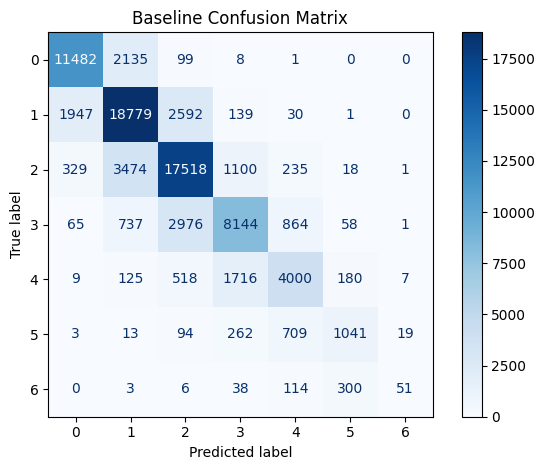

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 基线模型测试集混淆矩阵
cm_base = confusion_matrix(y_test_base, y_test_pred_base)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base)
disp_base.plot(cmap='Blues', values_format='d')
plt.title('Baseline Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print('基线模型分类报告:')
print(classification_report(y_test_base, y_test_pred_base, digits=4))

基线模型分类报告:
              precision    recall  f1-score   support

           1     0.8299    0.8366    0.8332     13725
           2     0.7433    0.7995    0.7704     23488
           3     0.7360    0.7726    0.7538     22675
           4     0.7139    0.6340    0.6716     12845
           5     0.6719    0.6102    0.6396      6555
           6     0.6514    0.4862    0.5568      2141
           7     0.6456    0.0996    0.1726       512

    accuracy                         0.7446     81941
   macro avg     0.7131    0.6055    0.6283     81941
weighted avg     0.7424    0.7446    0.7411     81941



: 

In [ ]:
# 自动分批删减 + 早停规则（先20万分层样本，再全量复核）
from copy import deepcopy

# 早停参数（可按需求调整）
BATCH_SIZE = 2                 # 每轮新增删除特征数
MAX_REMOVE = 20                # 最多删除特征数
F1_DROP_TOL = 0.002            # 允许的test_f1下降阈值
USE_CV_GATE = True             # 同时要求cv_f1也不过度下降
CV_DROP_TOL = 0.002

# 采样策略：先在20万分层样本上做ablation
USE_ABLATION_SAMPLE = True
ABLATION_SAMPLE_SIZE = 200_000

# 如果有业务上必须保留的特征，可写在这里
MUST_KEEP = set([])

if USE_ABLATION_SAMPLE and len(df) > ABLATION_SAMPLE_SIZE:
    _, df_ablation = train_test_split(
        df,
        test_size=ABLATION_SAMPLE_SIZE,
        random_state=123,
        stratify=df['grade']
    )
    print(f'使用分层样本做ablation: {len(df_ablation)} 行')
else:
    df_ablation = df.copy()
    print(f'使用全量数据做ablation: {len(df_ablation)} 行')

# 候选删除顺序：按基线模型Gini重要性从低到高
importance_rank = pd.Series(rf_base.feature_importances_, index=X_train_full.columns).sort_values()
candidate_cols = [c for c in importance_rank.index if c not in MUST_KEEP]

# 基线参考分数（来自第5个单元）
base_test_f1 = test_f1_base
base_cv_f1 = cv_scores_base['test_f1_weighted'].mean()

records = []
best_drop_cols = []
best_test_f1 = -1.0
best_cv_f1 = -1.0

for k in range(BATCH_SIZE, min(MAX_REMOVE, len(candidate_cols)) + 1, BATCH_SIZE):
    drop_cols = candidate_cols[:k]
    Xk = df_ablation.drop(columns=drop_cols + ['grade'])
    yk = df_ablation['grade']

    Xk_train_full, Xk_test, yk_train_full, yk_test = train_test_split(
        Xk, yk,
        test_size=0.1,
        random_state=123,
        stratify=yk
    )

    _, cv_scores_k, _, test_acc_k, test_f1_k = run_rf_experiment(
        Xk_train_full, yk_train_full, Xk_test, yk_test,
        deepcopy(model_params), cv,
        model_label=f'样本ablation-删减{k}个特征模型'
    )
    cv_f1_k = cv_scores_k['test_f1_weighted'].mean()

    records.append({
        'n_removed': k,
        'removed_features': drop_cols,
        'cv_f1_mean': cv_f1_k,
        'test_accuracy': test_acc_k,
        'test_f1_weighted': test_f1_k
    })

    # 更新当前最优（先看test_f1，再看cv_f1）
    if (test_f1_k > best_test_f1) or (np.isclose(test_f1_k, best_test_f1) and cv_f1_k > best_cv_f1):
        best_test_f1 = test_f1_k
        best_cv_f1 = cv_f1_k
        best_drop_cols = drop_cols

    # 早停：相对基线明显下降则停止（仅在用全量ablation时严格比较基线）
    if len(df_ablation) == len(df):
        test_drop_too_much = (base_test_f1 - test_f1_k) > F1_DROP_TOL
        cv_drop_too_much = (base_cv_f1 - cv_f1_k) > CV_DROP_TOL
        if test_drop_too_much and ((not USE_CV_GATE) or cv_drop_too_much):
            print(f'触发早停：删除{k}个特征后性能下降超过阈值。')
            break

ablation_df = pd.DataFrame(records)
display_cols = ['n_removed', 'cv_f1_mean', 'test_accuracy', 'test_f1_weighted']
if not ablation_df.empty:
    print('样本ablation结果（按test_f1从高到低）：')
    display(ablation_df[display_cols].sort_values('test_f1_weighted', ascending=False).reset_index(drop=True))
    print('样本阶段建议删除的特征:')
    print(best_drop_cols)
else:
    print('未生成ablation结果，请检查参数设置。')

# 全量复核：只对样本阶段最优方案做一次全量评估
selected_drop_cols = best_drop_cols
if len(selected_drop_cols) > 0 and len(df_ablation) < len(df):
    print('开始全量复核样本阶段最优删减方案...')
    Xv = df.drop(columns=selected_drop_cols + ['grade'])
    yv = df['grade']
    Xv_train_full, Xv_test, yv_train_full, yv_test = train_test_split(
        Xv, yv,
        test_size=0.1,
        random_state=123,
        stratify=yv
    )
    _, cv_scores_v, _, test_acc_v, test_f1_v = run_rf_experiment(
        Xv_train_full, yv_train_full, Xv_test, yv_test,
        deepcopy(model_params), cv,
        model_label='全量复核-样本最优删减模型'
    )
    cv_f1_v = cv_scores_v['test_f1_weighted'].mean()
    print(f'全量复核 test_f1={test_f1_v:.4f}, 基线 test_f1={base_test_f1:.4f}')
    print(f'全量复核 cv_f1={cv_f1_v:.4f}, 基线 cv_f1={base_cv_f1:.4f}')

使用分层样本做ablation: 200000 行
样本ablation-删减2个特征模型CV准确率: 0.6783 +/- 0.0029
样本ablation-删减2个特征模型CV加权F1: 0.6728 +/- 0.0029
样本ablation-删减2个特征模型测试集准确率: 0.6884
样本ablation-删减2个特征模型测试集加权F1: 0.6833
样本ablation-删减4个特征模型CV准确率: 0.6892 +/- 0.0031
样本ablation-删减4个特征模型CV加权F1: 0.6840 +/- 0.0030
样本ablation-删减4个特征模型测试集准确率: 0.6970
样本ablation-删减4个特征模型测试集加权F1: 0.6924
样本ablation-删减6个特征模型CV准确率: 0.6919 +/- 0.0029
样本ablation-删减6个特征模型CV加权F1: 0.6869 +/- 0.0029
样本ablation-删减6个特征模型测试集准确率: 0.7087
样本ablation-删减6个特征模型测试集加权F1: 0.7043
样本ablation-删减8个特征模型CV准确率: 0.6992 +/- 0.0013
样本ablation-删减8个特征模型CV加权F1: 0.6945 +/- 0.0014
样本ablation-删减8个特征模型测试集准确率: 0.7137
样本ablation-删减8个特征模型测试集加权F1: 0.7095
样本ablation-删减10个特征模型CV准确率: 0.7189 +/- 0.0022
样本ablation-删减10个特征模型CV加权F1: 0.7147 +/- 0.0021
样本ablation-删减10个特征模型测试集准确率: 0.7281
样本ablation-删减10个特征模型测试集加权F1: 0.7242
样本ablation-删减12个特征模型CV准确率: 0.7062 +/- 0.0030
样本ablation-删减12个特征模型CV加权F1: 0.7014 +/- 0.0030
样本ablation-删减12个特征模型测试集准确率: 0.7177
样本ablation-删减12个特征模型测试集加权F1: 0.7135
样本ablation-删减14个特征

,n_removed,cv_f1_mean,test_accuracy,test_f1_weighted
0,18,0.749505,0.76030,0.757315
1,20,0.742044,0.75515,0.751706
2,16,0.715364,0.72870,0.725063
3,14,0.713122,0.72865,0.724966
4,10,0.714669,0.72810,0.724236
5,12,0.701419,0.71775,0.713531
6,8,0.694484,0.71375,0.709532
7,6,0.686887,0.70875,0.704337
8,4,0.684042,0.69705,0.692354
9,2,0.672839,0.68835,0.683344


样本阶段建议删除的特征:
['acc_now_delinq', 'collections_12_mths_ex_med', 'total_rec_late_fee', 'collection_recovery_fee', 'recoveries', 'pub_rec', 'tot_coll_amt', 'delinq_2yrs', 'home_ownership', 'initial_list_status', 'last_credit_pull_d', 'loan_status', 'emp_length', 'verification_status', 'addr_state_', 'open_acc', 'total_acc', 'inq_last_6mths']
开始全量复核样本阶段最优删减方案...
全量复核-样本最优删减模型CV准确率: 0.8071 +/- 0.0014
全量复核-样本最优删减模型CV加权F1: 0.8052 +/- 0.0014


In [ ]:
# 学习曲线 + 参数范围收窄（快速诊断版）
from sklearn.model_selection import learning_curve, validation_curve

# 诊断采样（分层20万）
DIAG_SAMPLE_SIZE = 200_000
if len(df) > DIAG_SAMPLE_SIZE:
    _, df_diag = train_test_split(
        df,
        test_size=DIAG_SAMPLE_SIZE,
        random_state=123,
        stratify=df['grade']
    )
else:
    df_diag = df.copy()

X_diag = df_diag.drop('grade', axis=1)
y_diag = df_diag['grade']

cv_quick = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)
rf_diag = RandomForestClassifier(**model_params)

# 1) 学习曲线：看是否已经接近平台
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=rf_diag,
    X=X_diag,
    y=y_diag,
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0],
    cv=cv_quick,
    scoring='f1_weighted',
    n_jobs=1
 )

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(7, 4))
plt.plot(train_sizes, train_mean, marker='o', label='train_f1')
plt.plot(train_sizes, valid_mean, marker='o', label='valid_f1')
plt.title('Learning Curve (Weighted F1)')
plt.xlabel('Training Samples')
plt.ylabel('Weighted F1')
plt.legend()
plt.tight_layout()
plt.show()

if len(valid_mean) >= 2:
    gain_tail = valid_mean[-1] - valid_mean[-2]
    print(f'学习曲线末段提升: {gain_tail:.5f}')
    if gain_tail < 0.001:
        print('结论: 学习曲线接近平台，可优先缩小参数搜索范围。')
    else:
        print('结论: 仍有提升空间，可保留适度搜索。')

# 2) n_estimators 验证曲线：定位树数平台
n_grid = [40, 80, 120, 160, 220]
tr_n, va_n = validation_curve(
    estimator=RandomForestClassifier(
        criterion=model_params['criterion'],
        max_depth=model_params['max_depth'],
        max_features=model_params['max_features'],
        min_samples_leaf=model_params['min_samples_leaf'],
        min_samples_split=model_params['min_samples_split'],
        random_state=model_params['random_state'],
        class_weight=model_params['class_weight'],
        n_jobs=RF_N_JOBS
    ),
    X=X_diag,
    y=y_diag,
    param_name='n_estimators',
    param_range=n_grid,
    cv=cv_quick,
    scoring='f1_weighted',
    n_jobs=1
 )

n_valid_mean = va_n.mean(axis=1)
plt.figure(figsize=(7, 4))
plt.plot(n_grid, n_valid_mean, marker='o')
plt.title('Validation Curve: n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('CV Weighted F1')
plt.tight_layout()
plt.show()

best_idx = int(np.argmax(n_valid_mean))
best_n = n_grid[best_idx]
print(f'n_estimators候选最优: {best_n}')

# 根据曲线给出收窄范围（可直接用于下一轮RandomizedSearch）
n_low = max(40, best_n - 40)
n_high = min(260, best_n + 40)
suggested_param_space = {
    'n_estimators': (n_low, n_high),
    'max_depth': (16, 40),
    'min_samples_split': (4, 20),
    'min_samples_leaf': (2, 12),
    'max_features': ['sqrt', 0.3, 0.5],
    'criterion': ['gini', 'entropy']
}
print('建议下一轮搜索空间:')
print(suggested_param_space)

In [ ]:
# 改进模型：使用自动删减结果；若不存在则回退到手动删两列
default_drop_cols = ['addr_state_', 'purpose_']
drop_cols_final = selected_drop_cols if ('selected_drop_cols' in globals() and len(selected_drop_cols) > 0) else default_drop_cols
print(f'本轮删除特征数: {len(drop_cols_final)}')
print('删除特征列表:', drop_cols_final)

df2 = df.drop(drop_cols_final, axis=1)

X2 = df2.drop('grade', axis=1)
y2 = df2['grade']

# 同样采用分层切分，保证与基线可比
X2_train_full, X2_test, y2_train_full, y2_test = train_test_split(
    X2, y2,
    test_size=0.1,
    random_state=123,
    stratify=y2
)

rf_drop, cv_scores_drop, y2_test_pred, test_accuracy_drop, test_f1_drop = run_rf_experiment(
    X2_train_full, y2_train_full, X2_test, y2_test, model_params, cv, model_label='改进模型'
 )

plot_top_feature_importances(
    rf_drop,
    X2_train_full.columns,
    title='Top Feature Importances (Drop Features by Ablation)',
    color='g',
    top_n=20
)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_drop = confusion_matrix(y2_test, y2_test_pred)
disp_drop = ConfusionMatrixDisplay(confusion_matrix=cm_drop)
disp_drop.plot(cmap='Greens', values_format='d')
plt.title('Drop-Features Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print('改进模型分类报告:')
print(classification_report(y2_test, y2_test_pred, digits=4))

comparison = pd.DataFrame({
    'model': ['baseline', 'drop_addr_state_purpose'],
    'test_accuracy': [test_accuracy_base, test_accuracy_drop],
    'test_f1_weighted': [test_f1_base, test_f1_drop],
    'cv_accuracy_mean': [cv_scores_base['test_accuracy'].mean(), cv_scores_drop['test_accuracy'].mean()],
    'cv_f1_mean': [cv_scores_base['test_f1_weighted'].mean(), cv_scores_drop['test_f1_weighted'].mean()]
})

comparison.sort_values(by='test_f1_weighted', ascending=False)